# Power per Dollar: Is Solar Better Than Wind?

Date: 15 May 2025

- Name: Lee Ki-Hoon
- University ID: 3040760060
- Email: kihoon_lee@berkeley.edu

-------

## Summary and Problem Statement
This project investigates the most effective way to deploy renewable energy systems under two distinct real-world constraints: land availability and budget limitations. The analysis focuses on three geographically and climatically diverse cities—Bath (UK), Seoul (South Korea), and Berkeley (USA)—to capture a wide range of solar irradiance and wind potential.

Section 1 Limited Land:
We explore how varying the Ground Coverage Ratio (GCR) affects solar farm performance. By simulating different panel spacing configurations on a fixed 200 × 200 meter plot, we identify the optimal GCR that maximizes energy output per dollar and per unit area, accounting for self-shading and packing density.

Section 2 Limited Budget:
With cost as the limiting factor, we compare the cost-effectiveness of solar farms vs. wind turbines in each location. By analyzing energy output per dollar invested in both technologies, we determine which provides better returns in each region.

-------

## Background information

Designing an optimal renewable energy system requires more than just selecting clean technologies—it involves balancing **land use**, **cost efficiency**, and **regional resource availability**. This project focuses on two of the most widely deployed renewable energy sources: **solar photovoltaic (PV) panels** and **wind turbines**. Though both are proven technologies, their suitability can vary drastically depending on environmental and economic constraints.

### Solar Photovoltaic Systems: Modular and Area-Constrained
- **Functioning:** Solar panels convert sunlight into electricity using semiconductor materials. Their output depends on irradiance, panel angle, and shading.
- **GCR Considerations:** When panels are packed tightly (high GCR), land use is maximized, but shading reduces performance. At low GCR, shading is minimized, but land is underutilized.

### Wind Turbines: High Output, High Footprint
- **Functioning:** Wind turbines harness kinetic energy from wind to turn generators. They perform well in areas with steady wind patterns but require large spacing and higher upfront capital.
- **Land vs. Cost Tradeoff:** A single 2 MW turbine may generate more annual energy than a large solar farm but at significantly higher cost and structural complexity.

### Why Bath, Seoul, and Berkeley?
1. **Bath (UK):** Low solar irradiance and moderate wind; useful for testing feasibility in marginal solar zones.
2. **Seoul (South Korea):** Distinct seasons and mixed solar/wind potential.
3. **Berkeley (USA):** High solar exposure, ideal for dense PV deployment.

Aside from the fact that I have lived in each of these places, I was always curious to know whether a PV farm would ever be more efficient than a wind farm in countries like the UK which is notorious for its minimal sunshine.

### Project Motivation
The core question is not just *which technology produces more energy*, but *which one does so more efficiently per dollar and per square meter*. By simulating various ground coverage ratios for solar and comparing them with fixed-cost wind scenarios, this project aims to offer a **techno-economic decision framework** for developers, planners, and policymakers.


## Land-Constrained Optimization: Impact of GCR on Solar Panel Deployment

In this section, we explore how the **Ground Coverage Ratio (GCR)** affects the number of solar modules that can be installed within a fixed land area of 200 × 200 meters (40,000 m²). The GCR defines how densely solar panels are spaced in the field and is mathematically expressed as the ratio between the module width and the row pitch (distance between module rows). 

As GCR increases, more modules can be placed per unit land, but this also increases the risk of **inter-row shading**, especially during low-sun-angle conditions. Conversely, low GCR reduces shading but results in underutilization of land.

We simulate GCR values ranging from 0.3 to 1.0 and calculate:
- Number of rows that fit within the 200 m length
- Number of modules per row along the 200 m width
- Total number of modules and corresponding system capacity in kilowatts (assuming 240 W per module)

The results are visualized to understand the trade-off between GCR and total installed capacity under land constraints.


-------

## Setup for the Photovoltaic Farm



In [1]:
pip install pvlib

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pvlib in c:\users\kihoo\appdata\local\programs\python\python312\lib\site-packages (0.12.0)




[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# --- SETUP ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pvlib

# Module and land specs
module_height = 1.65  # m (portrait orientation)
module_width = 0.992  # m
land_length = 200     # m
land_width = 200      # m
module_power = 240    # W
gcr_values = np.linspace(0.3, 1.0, 8)

# Locations
locations = [
    {"name": "Bath", "lat": 51.38, "lon": -2.36, "alt": 100},
    {"name": "Seoul", "lat": 37.56, "lon": 126.97, "alt": 38},
    {"name": "Berkeley", "lat": 37.87, "lon": -122.27, "alt": 52},
]

# Load module from Sandia DB
sandia_modules = pvlib.pvsystem.retrieve_sam('SandiaMod')
module = sandia_modules['Trina_TSM_240PA05__2013_']

# Temperature model params
temp_params = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']


## GCR Layout Table Calculation

To determine how many solar PV modules can be installed on a $200\,\text{m} \times 200\,\text{m}$ land area under varying ground coverage ratios (GCR), we compute the layout using the following logic:

- Let:
  - $GCR = \dfrac{\text{Module Width}}{\text{Row Pitch}}$

  - $\text{Row Pitch} = \dfrac{\text{Module Width}}{GCR}$

- For each GCR:

  - Number of rows: $\left\lfloor \dfrac{\text{Land Length}}{\text{Row Pitch}} \right\rfloor$

  - Modules per row: $\left\lfloor \dfrac{\text{Land Width}}{\text{Module Height}} \right\rfloor$

  - Total modules: $\text{Rows} \times \text{Modules per Row}$

  - Total capacity: $\dfrac{\text{Total Modules} \times \text{Module Power (W)}}{1000}$ (in kW)


,GCR,Rows,Modules per Row,Total Modules,Total Capacity (kW)
0,0.3,60,121,7260,1742.40
1,0.4,80,121,9680,2323.20
2,0.5,100,121,12100,2904.00
3,0.6,120,121,14520,3484.80
4,0.7,141,121,17061,4094.64
5,0.8,161,121,19481,4675.44
6,0.9,181,121,21901,5256.24
7,1.0,201,121,24321,5837.04


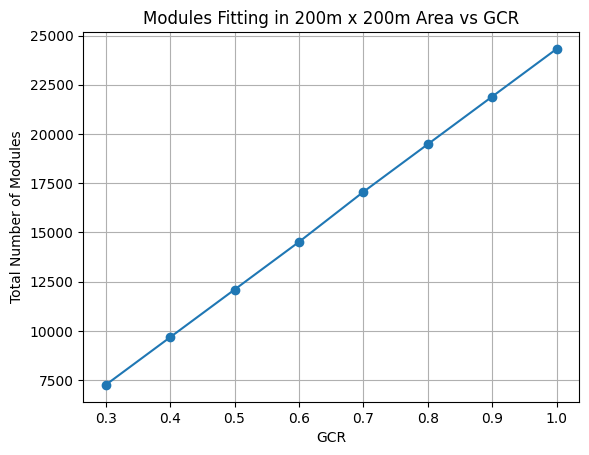

In [8]:
# --- GCR LAYOUT TABLE ---
layout_results = []
for gcr in gcr_values:
    row_pitch = module_width / gcr
    num_rows = int(land_length // row_pitch)
    modules_per_row = int(land_width // module_height)
    total_modules = num_rows * modules_per_row
    layout_results.append({
        'GCR': round(gcr, 2),
        'Rows': num_rows,
        'Modules per Row': modules_per_row,
        'Total Modules': total_modules,
        'Total Capacity (kW)': round(total_modules * module_power / 1000, 2)
    })

layout_df = pd.DataFrame(layout_results)
display(layout_df)

# Optional plot
plt.plot(layout_df['GCR'], layout_df['Total Modules'], marker='o')
plt.xlabel('GCR')
plt.ylabel('Total Number of Modules')
plt.title('Modules Fitting in 200m x 200m Area vs GCR')
plt.grid(True)
plt.show()


## Simulation of Annual Energy Output Across Locations and GCR Values

To evaluate how panel spacing (GCR) affects actual energy production, we simulated annual solar output across three locations—**Bath**, **Seoul**, and **Berkeley**—using typical meteorological year (TMY) weather data.

Using the PVLib library, we model:
- **Solar position** based on date, time, and location
- **Angle of incidence (AOI)** and irradiance on a tracking system with backtracking enabled
- **Temperature-adjusted cell performance** using SAPM models

For each GCR value, we calculate:
- The number of modules that fit on the land
- The effective irradiance and resulting DC power output over the year
- The total annual energy output in kilowatt-hours (kWh) and megawatt-hours (MWh)
- The energy output per module to assess shading-related efficiency losses

The results are plotted to visualize:
1. **Total energy output** as a function of GCR, showing how land utilization affects raw generation.
2. **Energy per module**, highlighting the trade-off between density and individual panel performance.
3. **Yearly Energy Output** as a function of total cost, showing the additional power gain per additional cost investment given the specific PV costs $80 per module.


In [9]:
# --- FULL PV SIMULATION ---
gcr_info = []
for gcr in gcr_values:
    row_pitch = module_width / gcr
    rows = int(land_length // row_pitch)
    modules_per_row = int(land_width // module_height)
    total_modules = rows * modules_per_row
    capacity_kw = total_modules * module_power / 1000
    gcr_info.append({"GCR": round(gcr, 2), "Modules": total_modules, "Capacity_kW": capacity_kw})

results = []
for loc in locations:
    weather, *_ = pvlib.iotools.get_pvgis_tmy(loc['lat'], loc['lon'])
    weather.index.name = "utc_time"

    solpos = pvlib.solarposition.get_solarposition(
        time=weather.index,
        latitude=loc['lat'],
        longitude=loc['lon'],
        altitude=loc['alt'],
        temperature=weather["temp_air"],
        pressure=weather["pressure"],
    )

    dni_extra = pvlib.irradiance.get_extra_radiation(weather.index)
    airmass = pvlib.atmosphere.get_relative_airmass(solpos['apparent_zenith'])
    pressure = pvlib.atmosphere.alt2pres(loc['alt'])
    am_abs = pvlib.atmosphere.get_absolute_airmass(airmass, pressure)

    for info in gcr_info:
        gcr = info["GCR"]
        modules = info["Modules"]

        tracking = pvlib.tracking.singleaxis(
            apparent_zenith=solpos['apparent_zenith'],
            apparent_azimuth=solpos['azimuth'],
            axis_tilt=0,
            axis_azimuth=180,
            max_angle=60,
            backtrack=True,
            gcr=gcr
        )

        tilt = tracking['surface_tilt'].fillna(0)
        azimuth = tracking['surface_azimuth'].fillna(0)

        aoi = pvlib.irradiance.aoi(
            tilt, azimuth, solpos['apparent_zenith'], solpos['azimuth']
        )

        irradiance = pvlib.irradiance.get_total_irradiance(
            tilt, azimuth,
            solpos['apparent_zenith'],
            solpos['azimuth'],
            weather['dni'],
            weather['ghi'],
            weather['dhi'],
            dni_extra=dni_extra,
            model='haydavies',
        )

        cell_temp = pvlib.temperature.sapm_cell(
            irradiance['poa_global'],
            weather['temp_air'],
            weather['wind_speed'],
            **temp_params,
        )

        effective_irrad = pvlib.pvsystem.sapm_effective_irradiance(
            irradiance['poa_direct'],
            irradiance['poa_diffuse'],
            am_abs,
            aoi,
            module,
        )

        dc = pvlib.pvsystem.sapm(effective_irrad, cell_temp, module)
        dc_power_kw = dc['p_mp'] * modules / 1000
        annual_energy_kwh = dc_power_kw.sum()

        results.append({
            "Location": loc['name'],
            "GCR": gcr,
            "Total Modules": modules,
            "Capacity (kW)": round(info["Capacity_kW"], 2),
            "Yearly Energy (kWh)": round(annual_energy_kwh, 2),
            "Energy per Module (kWh/module)": round(annual_energy_kwh / modules, 2)
        })


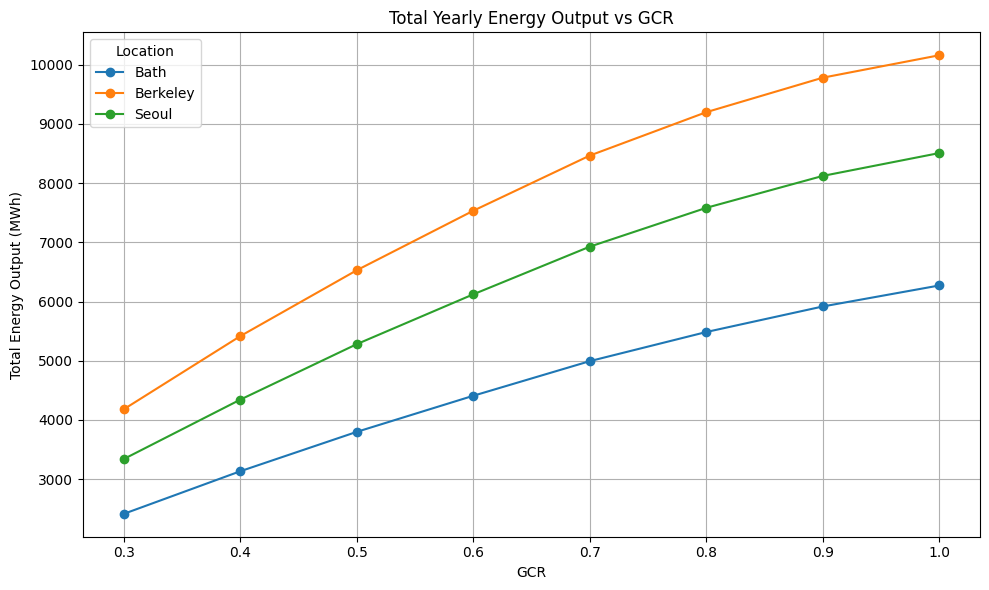

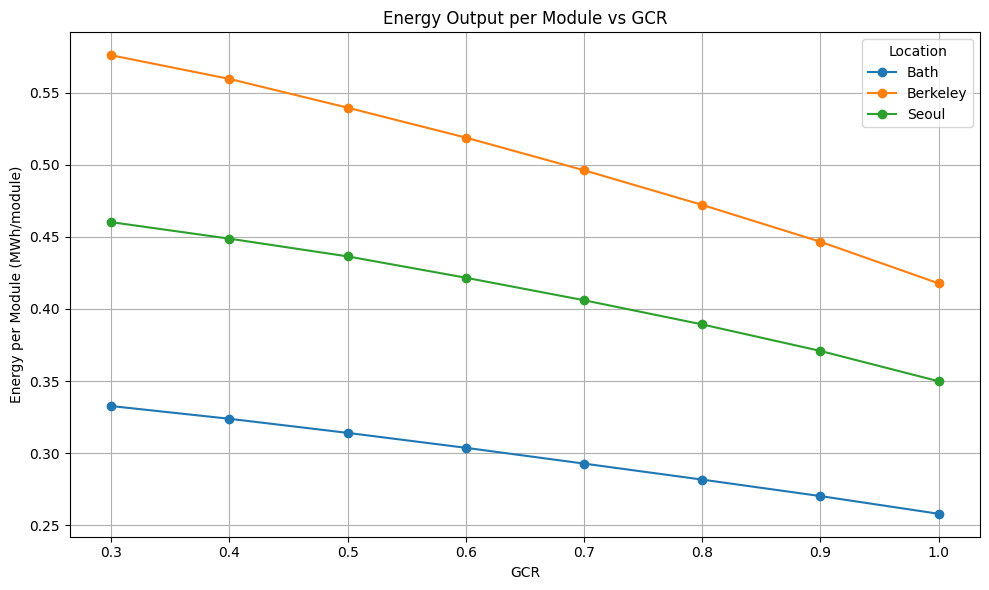

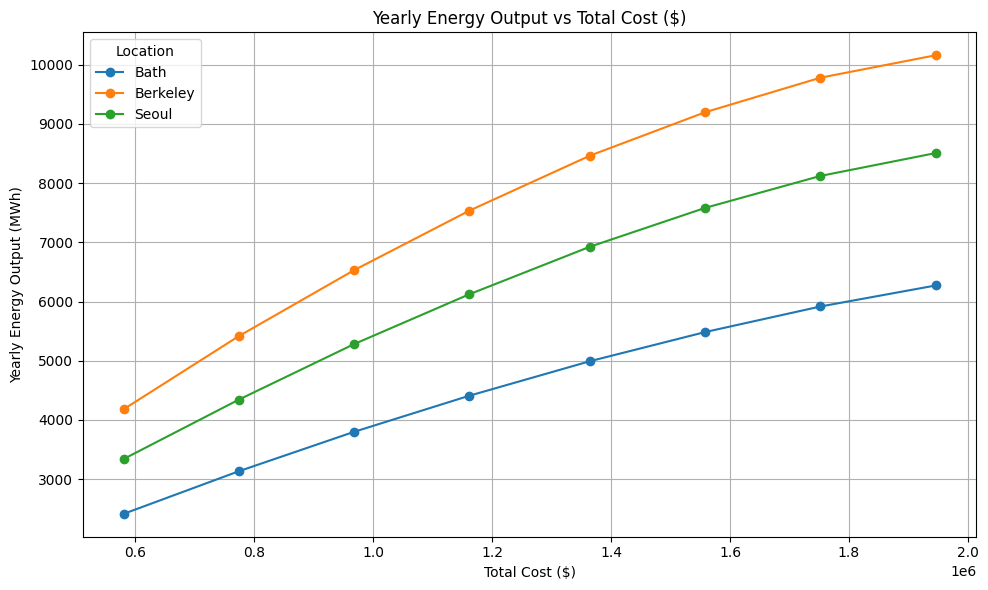

In [10]:
df = pd.DataFrame(results)
df["Yearly Energy (MWh)"] = df["Yearly Energy (kWh)"] / 1000
df["Energy per Module (MWh/module)"] = df["Energy per Module (kWh/module)"] / 1000
df["Cost ($)"] = df["Total Modules"] * 80

# Plot: Total Yearly Energy
pivot_total = df.pivot(index="GCR", columns="Location", values="Yearly Energy (MWh)")
pivot_total.plot(marker='o', figsize=(10,6))
plt.title("Total Yearly Energy Output vs GCR")
plt.xlabel("GCR")
plt.ylabel("Total Energy Output (MWh)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot: Energy per module
pivot_per_mod = df.pivot(index="GCR", columns="Location", values="Energy per Module (MWh/module)")
pivot_per_mod.plot(marker='o', figsize=(10,6))
plt.title("Energy Output per Module vs GCR")
plt.xlabel("GCR")
plt.ylabel("Energy per Module (MWh/module)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot: Cost vs Energy
pivot_cost_energy = df.pivot(index="Cost ($)", columns="Location", values="Yearly Energy (MWh)")
pivot_cost_energy.plot(marker='o', figsize=(10,6))
plt.title("Yearly Energy Output vs Total Cost ($)")
plt.xlabel("Total Cost ($)")
plt.ylabel("Yearly Energy Output (MWh)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Analysis: PV System Performance vs. GCR


### 1. Total Yearly Energy Output vs. GCR

- As GCR increases, the **row pitch** decreases, resulting in fewer rows and thus fewer total modules.
- Although closer spacing may increase **shading losses**, it allows a higher number of panels to be installed.
- As expected, the total energy output initially increases at higher GCRs due to more modules, but the rate of increase drops due to greater self-shading and reduced module count.

---

### 2. Energy Output per Module vs. GCR

As GCR increases:

- Modules are spaced farther apart
- Shading is reduced
- Energy per module increases

This can be approximated by:

$$
E_{\text{module}} \propto \text{Irradiance}_{\text{effective}} \times \text{ShadingFactor(GCR)}
$$

---

### 3. Energy Output vs. System Cost

Cost is computed as:

$$
\text{Cost} = N_{\text{modules}} \times \$80
$$

With increasing cost:

- While more modules result in higher energy output, the curve **flattens** due to diminishing returns, especially in low-irradiance locations like Bath.
- Berkeley shows the **highest energy return per dollar**, indicating optimal irradiance conditions.

---

Through this analysis, it was clear that adding more panels did not translate into a linear increase in power output. Given the limited land area, the optimal layout and GCR would ultimately depend on other factors: 

- The available budget for constructing the farm, 
- Whether the goal is to meet a specific power target, 
- To maximize energy output per module,
- Whether each module must achieve a minimum performance level. 

As a result, precisely identifying the optimal GCR value was deemed unnecessary as there were too many variables involved.

## PV Farm Simulation with Fixed Budget and GCR

Moving on we have decided to define a fixed investment budget of \$1,000,000. Additionally, the layout uses a fixed Ground Coverage Ratio (GCR) of 0.5 because it:

- Offers a **good compromise** between performance and land efficiency
- Avoids the diminishing returns seen at extremely low or high GCRs
- Matches well with **tracking configurations**, reducing mutual shading without underutilizing space.

---

### Setup and Budget Constraints

- **Investment**: \$1,000,000  
- **Module Cost**: \$80  
- **Modules per string**: 20  
- **GCR**: 0.5  
- **Module Width**: 0.992 m  
- **Module Height**: 1.65 m  
- **Land Area**: 200 m × 200 m  

---

### Layout Calculation

We calculate the number of modules that can physically fit on the plot as:

$$
\text{Row Pitch} = \frac{0.992}{0.5} = 1.984 \text{ m}
$$

$$
\text{Rows} = \left\lfloor \frac{200}{1.984} \right\rfloor = 100,\quad
\text{Modules per Row} = \left\lfloor \frac{200}{1.65} \right\rfloor = 121
$$

$$
\text{Total Modules (Land-limited)} = 100 \times 121 = 12,100
$$

Then, we determine the number of modules actually affordable under the budget:

$$
\text{Affordable Modules} = \left\lfloor \frac{1{,}000{,}000}{80} \right\rfloor = 12,500
$$

Since the **land constraint dominates**, we install **12,100 modules**, arranged in **100 rows of 121**.

---

### Simulation per City

For each location (Bath, Seoul, Berkeley), the simulation:

1. Retrieves Typical Meteorological Year (TMY) weather data  
2. Computes solar geometry and irradiance using PVLib  
3. Applies a single-axis tracking model with the given GCR  
4. Calculates PV cell temperature and effective irradiance  
5. Computes DC power using the Sandia PV model  
6. Aggregates daily energy and revenue over the year


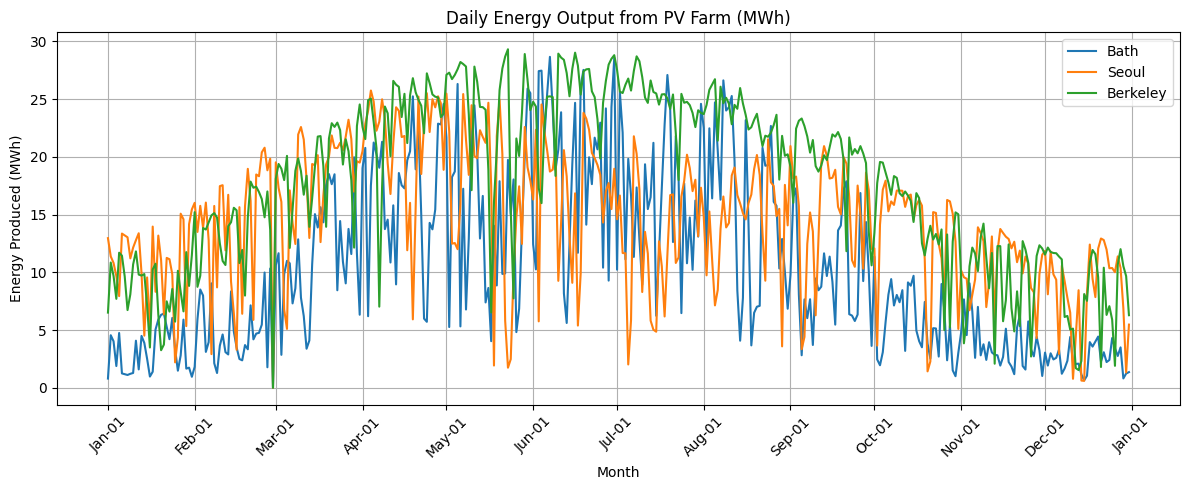

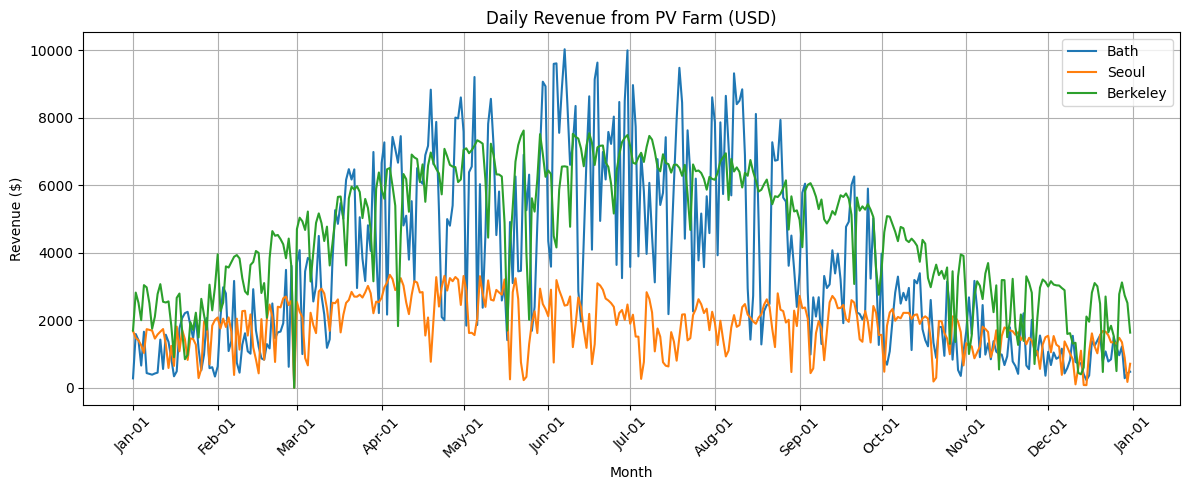

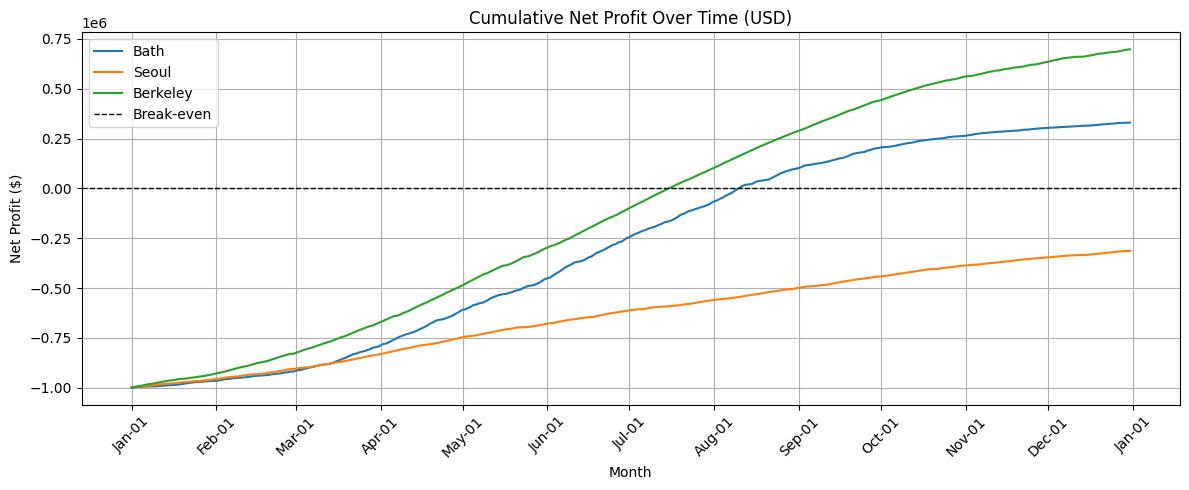

In [11]:
# Additional variables
investment_usd = 1_000_000
panel_cost = 80
modules_per_string = 20
gcr = 0.5
electricity_prices = {"Bath": 0.35, "Seoul": 0.13, "Berkeley": 0.26}

# Calculate how many modules can fit & are affordable
row_pitch = module_width / gcr
rows = int(land_length // row_pitch)
modules_per_row = int(land_width // module_height)
total_modules = rows * modules_per_row
max_affordable_modules = investment_usd // panel_cost
best_modules = min(total_modules, max_affordable_modules)
total_strings = best_modules // modules_per_string

# Storage
daily_energy_by_city = {}
daily_revenue_by_city = {}
cumulative_profit_by_city = {}

# --- Per-city PV simulation ---
for loc in locations:
    name = loc["name"]
    price = electricity_prices[name]

    weather, *_ = pvlib.iotools.get_pvgis_tmy(loc['lat'], loc['lon'])
    solpos = pvlib.solarposition.get_solarposition(
        time=weather.index, latitude=loc['lat'], longitude=loc['lon'],
        altitude=loc['alt'], temperature=weather["temp_air"], pressure=weather["pressure"]
    )

    tracking = pvlib.tracking.singleaxis(
        apparent_zenith=solpos['apparent_zenith'], apparent_azimuth=solpos['azimuth'],
        axis_tilt=0, axis_azimuth=180, max_angle=60, backtrack=True, gcr=gcr
    )

    tilt = tracking['surface_tilt'].fillna(0)
    azimuth = tracking['surface_azimuth'].fillna(0)
    dni_extra = pvlib.irradiance.get_extra_radiation(weather.index)
    airmass = pvlib.atmosphere.get_relative_airmass(solpos['apparent_zenith'])
    pressure = pvlib.atmosphere.alt2pres(loc['alt'])
    am_abs = pvlib.atmosphere.get_absolute_airmass(airmass, pressure)

    irradiance = pvlib.irradiance.get_total_irradiance(
        tilt, azimuth, solpos['apparent_zenith'], solpos['azimuth'],
        weather['dni'], weather['ghi'], weather['dhi'], dni_extra=dni_extra,
        model='haydavies'
    )

    cell_temp = pvlib.temperature.sapm_cell(
        irradiance['poa_global'], weather['temp_air'], weather['wind_speed'], **temp_params
    )

    aoi = pvlib.irradiance.aoi(tilt, azimuth, solpos['apparent_zenith'], solpos['azimuth'])
    effective_irrad = pvlib.pvsystem.sapm_effective_irradiance(
        irradiance['poa_direct'], irradiance['poa_diffuse'], am_abs, aoi, module
    )

    dc = pvlib.pvsystem.sapm(effective_irrad, cell_temp, module)
    dc_power = dc['p_mp'] * modules_per_string * total_strings / 1e6  # MW

    dc_power.index = dc_power.index.map(lambda t: t.replace(year=2000))  # Normalize for clean plots
    daily_energy = dc_power.clip(lower=0).resample('h').mean().resample('D').sum()
    daily_energy_by_city[name] = daily_energy

    daily_revenue = daily_energy * price * 1000
    daily_revenue_by_city[name] = daily_revenue
    cumulative_profit_by_city[name] = daily_revenue.cumsum() - investment_usd

# --- PLOT 1: Daily Energy Output ---
plt.figure(figsize=(12, 5))
for city, energy in daily_energy_by_city.items():
    plt.plot(energy.index, energy, label=city)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.title("Daily Energy Output from PV Farm (MWh)")
plt.xlabel("Month")
plt.ylabel("Energy Produced (MWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- PLOT 2: Daily Revenue ---
plt.figure(figsize=(12, 5))
for city, revenue in daily_revenue_by_city.items():
    plt.plot(revenue.index, revenue, label=city)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.title("Daily Revenue from PV Farm (USD)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- PLOT 3: Cumulative Profit ---
plt.figure(figsize=(12, 5))
for city, profit in cumulative_profit_by_city.items():
    plt.plot(profit.index, profit, label=city)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='Break-even')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.title("Cumulative Net Profit Over Time (USD)")
plt.xlabel("Month")
plt.ylabel("Net Profit ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---

### Plots and Interpretation

#### 1. Daily Energy Output

This plot shows the **daily energy produced** in MWh by the PV farm across all 365 days.

- Seasonal variation is clearly visible.
- Berkeley shows the greatest and most consistent output due to its stable irradiance.
- Bath has the lowest generation and more seasonal drop-off.

#### 2. Daily Revenue

To visualize how much a PV farm built with $1M of budget with GCR of 0.5, Revenue was computed using a fixed cost model:

$$
\text{Revenue} = \text{Energy} \times \text{Electricity Price}
$$

With electricity prices:
- Bath: \$0.35/kWh
- Seoul: \$0.13/kWh
- Berkeley: \$0.26/kWh

What was very interesting to see was that even if Bath generates less energy, the high price partly offsets the lower yield allowing it to surpass Seoul in terms of revenue generation over a year, even surpassing Berkeley during multiple days during summer despite receiving less sunlight.

#### 3. Cumulative Profit

Profit is calculated as:

$$
\text{Cumulative Profit} = \sum_{t=1}^{n} \text{Revenue}_t - \text{Investment}
$$

- The cumulative curve shows when (or if) the farm breaks even after the initial 1 million dollar investment to build the farm.
- Berkeley typically breaks even earliest, followed by Bath due to its greater electricity cost, allowing it to generate greater revenue. 
- Seoul despite receiving greater portion of sunlight than Bath, failed to break even in the first year due to its low electrcity cost.
- Both Berkeley and Bath managed to generate a profit in first year of 700 thousand dollars for Berkeley, and 300 thousand dollars for Bath (assuming zero maintenance costs or breakdown with 24/7/365 operation).

---

### Summary

| City      | Energy Yield | Electricity Price | Break-even Speed | Profit Potential |
|-----------|--------------|-------------------|-------------------|------------------|
| Bath      | Low          | High              | Fast              | Good             |
| Seoul     | Medium       | Medium            | Slow              | Poor             |
| Berkeley  | High         | Medium-High       | Fast              | Excellent        |


## Wind Turbine Installation Capacity Analysis

This section estimates how many small-scale wind turbines (10 m rotor diameter) can be installed, subject to the same spatial and budgetary constraints, in hopes of comparing its performance to the above PV farm.

We chose a wind turbine with a 10 m rotor diameter because it offers a practical balance between power output, spacing requirements, and cost. Unlike large utility-scale turbines, which require over 100,000 m² per unit, a 10 m turbine with standard 5D spacing fits well within our 200 m × 200 m land constraint. Additionally, its lower cost 50,000 aligns with the 1 million budget, allowing us to realistically simulate a multi-turbine setup on a compact site.


---

### Land and Turbine Specifications

- **Turbine rotor diameter**:  
  $$ D = 10\ \text{m} $$
- **Spacing factor**: 5 (industry standard for minimizing wake losses)

Thus, each turbine requires:

$$
\text{Turbine Spacing} = 5 \times D = 50\ \text{m}
$$

$$
A_{\text{per turbine}} = 50\,\text{m} \times 50\,\text{m} = 2{,}500\ \text{m}^2
$$

---

### Budget Constraints

- **Total budget**: \$1,000,000  
- **Turbine cost**: \$50,000 per unit

So the **maximum number of turbines** based on cost is:

$$
\left\lfloor \frac{\$1{,}000{,}000}{\$50{,}000} \right\rfloor = 20
$$

---

### Final Installable Turbine Count

We apply both constraints (land and cost):

$$
N_{\text{area}} = \left\lfloor \frac{40{,}000}{2{,}500} \right\rfloor = 16
$$

$$
N_{\text{cost}} = 20
$$

$$
N_{\text{installable}} = \min(N_{\text{area}}, N_{\text{cost}}) = \boxed{16}
$$

---

### Summary

| Parameter                  | Value                 |
|---------------------------|-----------------------|
| Max turbines by land      | 16                    |
| Max turbines by budget    | 20                    |
| **Installable turbines**  | **16**                |
| Total cost                | \$800,000             |
| Total area used           | 40,000 × 0.625 = 25,000 m² |
| Land usage                | 62.5%                 |

This analysis ensures that turbine placement respects both **spatial wake-loss constraints** and **capital limits**, making the scenario realistic for small-scale onshore wind farm planning.


In [12]:
# --- Land dimensions ---
land_length = 200  # meters
land_width = 200   # meters
total_land_area = land_length * land_width  # m²

# --- Wind turbine specs ---
turbine_diameter = 10  # meters
spacing_factor = 5     # distance between turbines in terms of rotor diameter
turbine_spacing = turbine_diameter * spacing_factor  # meters
area_per_turbine = turbine_spacing ** 2  # m² required per turbine

# --- Budget ---
investment_usd = 1_000_000
turbine_cost = 50_000  # USD per turbine

# --- Calculate limits ---
max_turbines_by_area = total_land_area // area_per_turbine
max_turbines_by_cost = investment_usd // turbine_cost
max_turbines = int(min(max_turbines_by_area, max_turbines_by_cost))

# --- Output summary ---
print(f"Max turbines by area: {int(max_turbines_by_area)}")
print(f"Max turbines by cost: {int(max_turbines_by_cost)}")
print(f"Installable turbines: {max_turbines}")
print(f"Total cost: ${max_turbines * turbine_cost:,}")
print(f"Total area used: {max_turbines * area_per_turbine:.0f} m²")
print(f"Land usage: {100 * max_turbines * area_per_turbine / total_land_area:.1f}%")


Max turbines by area: 16
Max turbines by cost: 20
Installable turbines: 16
Total cost: $800,000
Total area used: 40000 m²
Land usage: 100.0%


## Wind Turbine Performance Simulation

### Model Configuration

- **Rotor Diameter**: 10 m  
- **Hub Height**: 30 m  
- **Rated Power**: 10 kW  
- **Cut-in / Rated / Cut-out Speeds**: 3 m/s, 12 m/s, 25 m/s  
- **Air Density**: 1.225 kg/m³  
- **Spacing**: 5 rotor diameters (50 m) between turbines  
- **Installable Turbines**:  
  $$ N = \min\left( \left\lfloor \frac{A_{\text{land}}}{A_{\text{per turbine}}} \right\rfloor,\ \left\lfloor \frac{\$1{,}000{,}000}{\$50{,}000} \right\rfloor \right) = 16 $$

---

### Simulation Process

For each city (**Bath**, **Seoul**, **Berkeley**), the following steps are executed:

1. Load hourly wind speed data, attained from real weather data, and scale it to 30 m hub height using the power law:
   $$
   v_{30} = v_{10} \left( \frac{30}{10} \right)^{0.14}
   $$
2. Apply a simplified power curve:

   - $P = 0$ below 3 m/s and above 25 m/s  

   - $P = \frac{1}{2} \rho A v^3$ from 3–12 m/s  

   - $P = 10$ kW from 12–25 m/s

3. Multiply output by the number of turbines (16) and convert to daily MWh.
4. Multiply daily energy by local electricity price to estimate revenue.
5. Calculate cumulative net profit over the year:
   $$
   \text{Profit}(t) = \sum_{i=1}^{t} \text{Revenue}_i - \text{Investment}
   $$


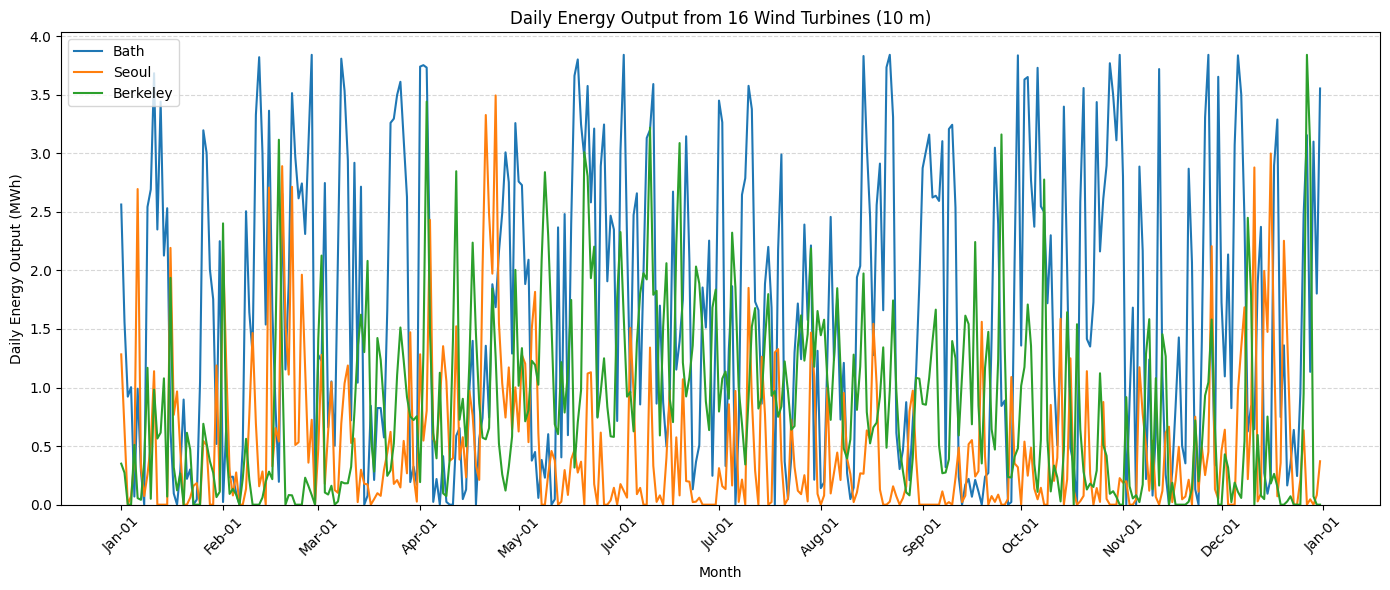

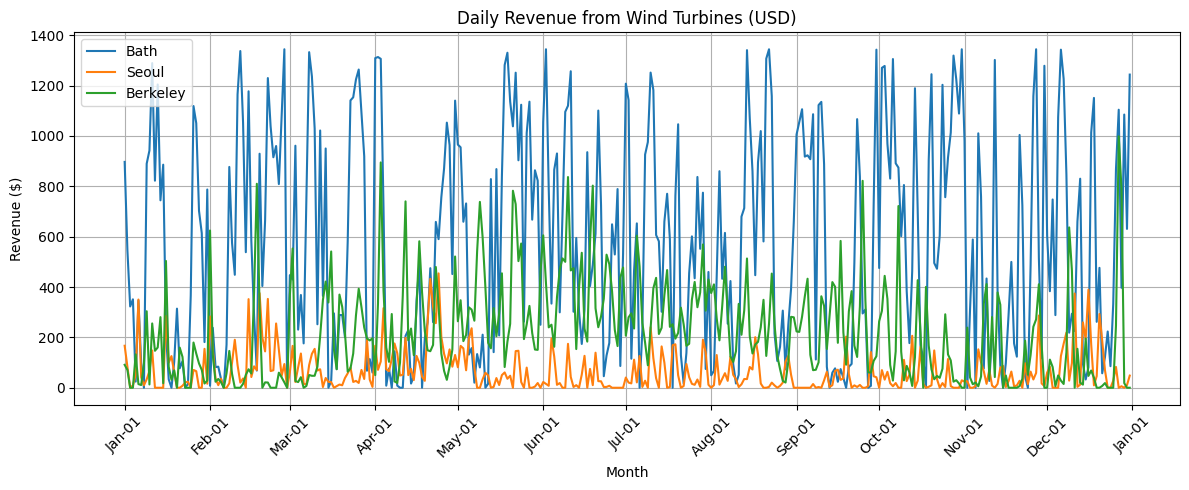

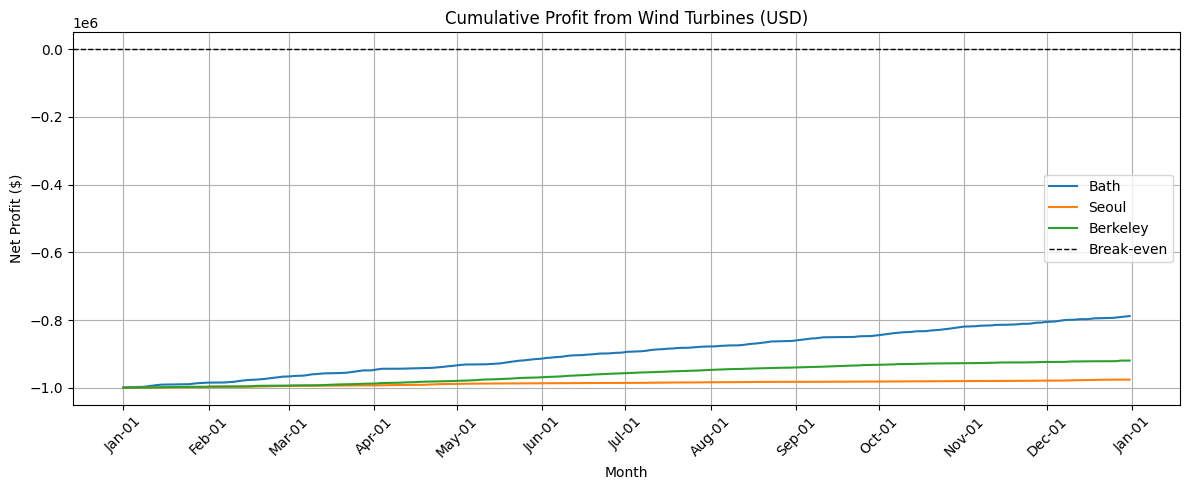

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pvlib

# --- Constants for 10 m wind turbine ---
rho = 1.225  # air density in kg/m³
turbine_diameter = 10  # meters
turbine_radius = turbine_diameter / 2
turbine_area = np.pi * turbine_radius**2  # rotor swept area
hub_height = 30  # meters
cut_in = 3       # m/s
rated = 12       # m/s
cut_out = 25     # m/s
rated_power_kw = 10  # Small turbine

# --- Plot and investment ---
land_length = 200  # m
land_width = 200   # m
plot_area = land_length * land_width
spacing = turbine_diameter * 5  # 5D spacing
area_per_turbine = spacing**2
max_by_area = plot_area // area_per_turbine

investment_usd = 1_000_000
turbine_cost = 50_000
max_by_cost = investment_usd // turbine_cost

max_turbines = int(min(max_by_area, max_by_cost))

# --- Electricity prices ---
electricity_prices = {"Bath": 0.35, "Seoul": 0.13, "Berkeley": 0.26}
locations = [
    {"name": "Bath", "lat": 51.38, "lon": -2.36, "alt": 100},
    {"name": "Seoul", "lat": 37.56, "lon": 126.97, "alt": 38},
    {"name": "Berkeley", "lat": 37.87, "lon": -122.27, "alt": 52},
]

# --- Power curve function ---
def scale_wind_speed(v_ref, h, h_ref=10, alpha=0.14):
    return v_ref * (h / h_ref) ** alpha

def wind_power_output(v):
    """Simplified wind power output curve"""
    P = np.zeros_like(v)
    mask_cut_in = (v >= cut_in) & (v < rated)
    mask_rated = (v >= rated) & (v <= cut_out)
    P[mask_cut_in] = 0.5 * rho * turbine_area * v[mask_cut_in]**3 / 1e3  # in kW
    P[mask_rated] = rated_power_kw
    return np.clip(P, 0, rated_power_kw)

# --- Results storage ---
daily_energy_by_city = {}
daily_revenue_by_city = {}
cumulative_profit_by_city = {}

# --- Simulation loop ---
for loc in locations:
    name = loc["name"]
    price = electricity_prices[name]

    weather, *_ = pvlib.iotools.get_pvgis_tmy(loc['lat'], loc['lon'])
    wind_speed_10m = weather['wind_speed']
    wind_speed_hub = scale_wind_speed(wind_speed_10m, hub_height)

    wind_power_kw = wind_power_output(wind_speed_hub.values)
    power_series = pd.Series(wind_power_kw, index=wind_speed_hub.index)
    power_series.index = power_series.index.map(lambda t: t.replace(year=2000))

    daily_energy = power_series.clip(lower=0).resample('h').mean().resample('D').sum() * max_turbines / 1000  # MWh
    daily_energy_by_city[name] = daily_energy

    daily_revenue = daily_energy * price * 1000
    daily_revenue_by_city[name] = daily_revenue

    cumulative_profit_by_city[name] = daily_revenue.cumsum() - investment_usd

# --- PLOT 1: Daily Energy Output (Line Plot) ---
plt.figure(figsize=(14, 6))
for city, energy in daily_energy_by_city.items():
    plt.plot(energy.index, energy, label=city)

plt.ylim(bottom=0)
plt.xlabel("Month")
plt.ylabel("Daily Energy Output (MWh)")
plt.title(f"Daily Energy Output from {max_turbines} Wind Turbines (10 m)")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- PLOT 2: Daily Revenue ---
plt.figure(figsize=(12, 5))
for city, rev in daily_revenue_by_city.items():
    plt.plot(rev.index, rev, label=city)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.title("Daily Revenue from Wind Turbines (USD)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- PLOT 3: Cumulative Profit ---
plt.figure(figsize=(12, 5))
for city, profit in cumulative_profit_by_city.items():
    plt.plot(profit.index, profit, label=city)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='Break-even')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.title("Cumulative Profit from Wind Turbines (USD)")
plt.xlabel("Month")
plt.ylabel("Net Profit ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---

### Plots Overview

#### 1. Daily Energy Output (MWh)

- Reflects seasonal wind trends with alot of fluctuations for each city throughout the year.
- Bath produced the greatest energy, followed by Berkeley and Seoul.

#### 2. Daily Revenue (\$)

- After scaling by revenue, the differences became more pronounced with Bath clearly generating the greatest revenue, followed by Berkeley, then lastly, Seoul.
- The above trend was almost consistent throughout the whole year.

#### 3. Cumulative Profit (\$)

- Although Bath took lead in this metric it was only a little over 1/5 of the way to breaking even by the end of the year.
- Berkeley wasn't even 1/10 the way there, with Seoul generating less than half of Berkeley's revenue.

It was interesting to observe that, with the 10 m wind turbine selected, the overall revenue generated by the wind farms was significantly lower than that of the PV farm despite using the same investment budget. This result highlights how sensitive wind energy systems are to location, showing a key advantage of PV systems: their greater consistency and reliability across different climates.

---

### Summary

| Location  | Energy Yield | Electricity Price | Break-even Speed |
|-----------|--------------|-------------------|------------------|
| Bath      | High         | High              | Slow             |
| Seoul     | Low          | Medium            | Slowest          |
| Berkeley  | Medium       | Medium-High       | Slower           |

This analysis supports **location-specific wind energy planning**, balancing wind resource quality with market electricity prices and land constraints.

-----

## Improving the performance

Because of the disappopinting results of the previous wind turbine farm, in this section we explored the performance of **one very large wind turbine** installed on a 200m x 200m plot of land. Unlike earlier scenarios with multiple smaller turbines, this approach allows us to:

- **Ignore spacing constraints**, since we are only installing one unit.
- Focus entirely on **maximizing output per turbine**.
- Evaluate if a single, high-capacity turbine is a viable investment under a $1,000,000 budget.

We model a utility-scale 80-meter diameter turbine with a hub height of 80 meters and a rated power of 1.5 MW and a rough cost of ~1 million dollars. Wind speeds were again adjusted to hub height using a logarithmic wind profile, and the power output is computed using a simplified power curve model as mentioned before. 

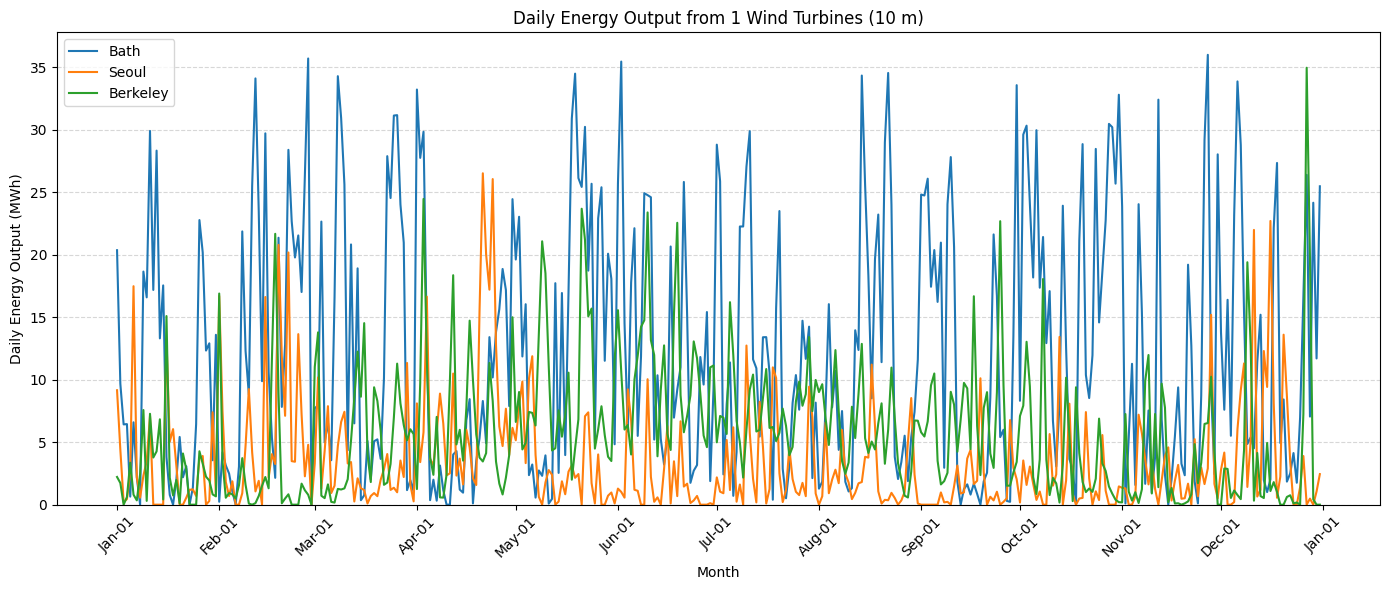

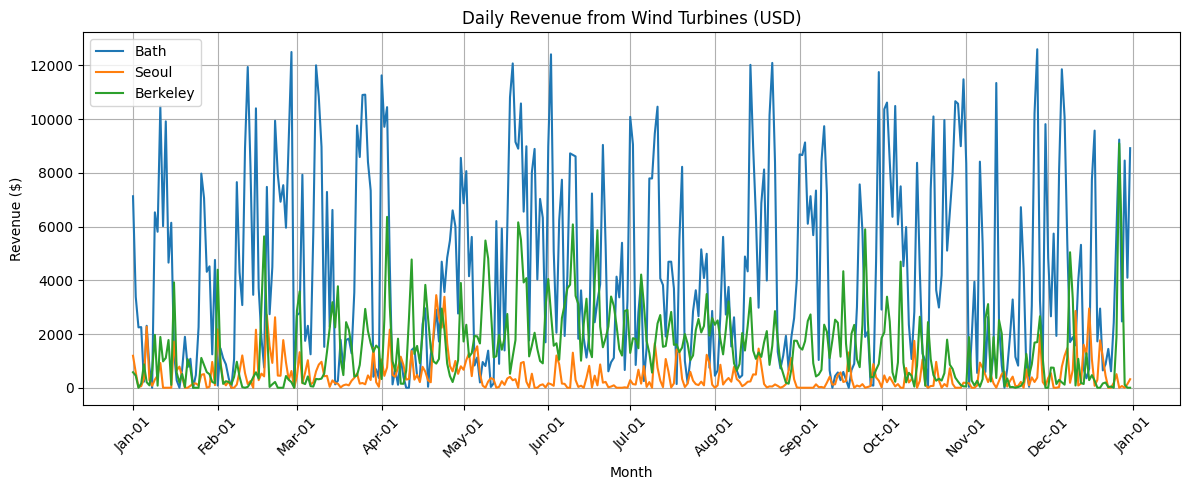

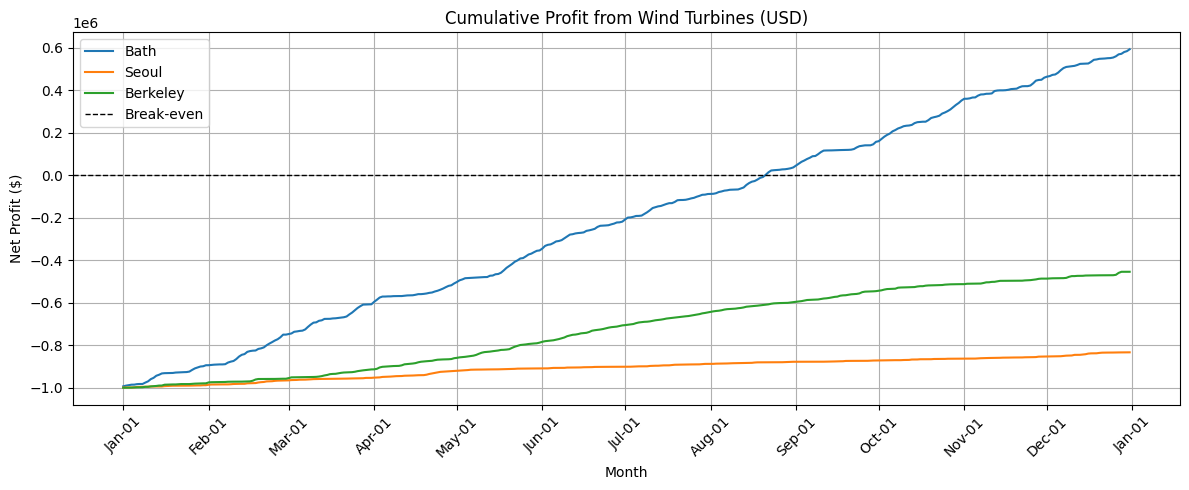

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pvlib

# --- Constants for 10 m wind turbine ---
rho = 1.225  # air density in kg/m³
turbine_diameter = 80  # meters
turbine_radius = turbine_diameter / 2
turbine_area = np.pi * turbine_radius**2  # rotor swept area
hub_height = 80  # meters
cut_in = 3       # m/s
rated = 12       # m/s
cut_out = 25     # m/s
rated_power_kw = 1500  

# --- Plot and investment ---
land_length = 200  # m
land_width = 200   # m
plot_area = land_length * land_width
spacing = turbine_diameter * 5  # 5D spacing
area_per_turbine = spacing**2
max_by_area = plot_area // area_per_turbine

investment_usd = 1_000_000
turbine_cost = 1_000_000
max_by_cost = investment_usd // turbine_cost

max_turbines = 1

# --- Electricity prices ---
electricity_prices = {"Bath": 0.35, "Seoul": 0.13, "Berkeley": 0.26}
locations = [
    {"name": "Bath", "lat": 51.38, "lon": -2.36, "alt": 100},
    {"name": "Seoul", "lat": 37.56, "lon": 126.97, "alt": 38},
    {"name": "Berkeley", "lat": 37.87, "lon": -122.27, "alt": 52},
]

# --- Power curve function ---
def scale_wind_speed(v_ref, h, h_ref=10, alpha=0.14):
    return v_ref * (h / h_ref) ** alpha

def wind_power_output(v):
    """Simplified wind power output curve"""
    P = np.zeros_like(v)
    mask_cut_in = (v >= cut_in) & (v < rated)
    mask_rated = (v >= rated) & (v <= cut_out)
    P[mask_cut_in] = 0.5 * rho * turbine_area * v[mask_cut_in]**3 / 1e3  # in kW
    P[mask_rated] = rated_power_kw
    return np.clip(P, 0, rated_power_kw)

# --- Results storage ---
daily_energy_by_city = {}
daily_revenue_by_city = {}
cumulative_profit_by_city = {}

# --- Simulation loop ---
for loc in locations:
    name = loc["name"]
    price = electricity_prices[name]

    weather, *_ = pvlib.iotools.get_pvgis_tmy(loc['lat'], loc['lon'])
    wind_speed_10m = weather['wind_speed']
    wind_speed_hub = scale_wind_speed(wind_speed_10m, hub_height)

    wind_power_kw = wind_power_output(wind_speed_hub.values)
    power_series = pd.Series(wind_power_kw, index=wind_speed_hub.index)
    power_series.index = power_series.index.map(lambda t: t.replace(year=2000))

    daily_energy = power_series.clip(lower=0).resample('h').mean().resample('D').sum() * max_turbines / 1000  # MWh
    daily_energy_by_city[name] = daily_energy

    daily_revenue = daily_energy * price * 1000
    daily_revenue_by_city[name] = daily_revenue

    cumulative_profit_by_city[name] = daily_revenue.cumsum() - investment_usd

# --- PLOT 1: Daily Energy Output (Line Plot) ---
plt.figure(figsize=(14, 6))
for city, energy in daily_energy_by_city.items():
    plt.plot(energy.index, energy, label=city)

plt.ylim(bottom=0)
plt.xlabel("Month")
plt.ylabel("Daily Energy Output (MWh)")
plt.title(f"Daily Energy Output from {max_turbines} Wind Turbines (10 m)")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- PLOT 2: Daily Revenue ---
plt.figure(figsize=(12, 5))
for city, rev in daily_revenue_by_city.items():
    plt.plot(rev.index, rev, label=city)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.title("Daily Revenue from Wind Turbines (USD)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- PLOT 3: Cumulative Profit ---
plt.figure(figsize=(12, 5))
for city, profit in cumulative_profit_by_city.items():
    plt.plot(profit.index, profit, label=city)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='Break-even')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.title("Cumulative Profit from Wind Turbines (USD)")
plt.xlabel("Month")
plt.ylabel("Net Profit ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Results 

By deploying a single large turbine (eight times the size of the original), we observed a significant increase in both power generation and therefore the revenue. While the revenue gains in Seoul and Berkeley were noticeable, they still fell short of breaking even and the levels achieved by their respective PV farms. Bath, however was a different story. Not only did it break even by mid-August, but it also went on to generate approximately 600 thousand dollars in profit—roughly double the profit of the PV system. This demonstrates how, under the right conditions, large-scale wind installations can outperform PV both in return and payback speed.

While a larger turbine has its pros:

- **Higher efficiency** due to stronger winds at higher altitudes.
- **Lower maintenance per kW** (fewer moving parts overall).
- **Space-efficient** when only one unit is needed.
- **Easier grid integration** with a single power stream.
- **Ideal in high-wind locations** with sufficient hub height.

It also has cons:

- **Very high upfront cost and risk** — failure affects entire system.
- **Challenging logistics** — transporting large blades and towers is complex.
- **Longer downtime impact** — entire system goes offline during repairs.
- **Less adaptable** to varied terrain or wind microclimates.

This project demonstrates that while wind farms have the potential to generate more power and revenue per dollar invested, they are also significantly more sensitive to location compared to PV farms. As such, the results highlight the importance of careful planning, site assessment, and design optimization. For engineers, this highlights the need to thoroughly evaluate local conditions and constraints such as available land, budget, or policy in order to maximize energy yield and investment return in real-world renewable energy projects.

Some future work could involve incorporating a dynamic electricity pricing model that reflects real-world market behavior, where prices vary by season, time of day, and demand levels. For instance, electricity is often more expensive during peak hours (e.g., late afternoon and early evening) and in winter months due to higher demand. By simulating these variations, the model would provide a more realistic estimate of revenue and payback periods—especially for solar systems, which tend to generate during peak price hours. This extension would allow for evaluating time-sensitive performance of each energy system and could reveal additional advantages or drawbacks of PV or wind based on their generation profiles. Ultimately, this would lead to more informed investment decisions and help tailor designs to market-specific conditions, maximizing both energy efficiency and financial return.    

----

## Conclusions


This project explored the effectiveness of photovoltaic and wind energy systems across three global locations: Bath, Seoul, and Berkeley. We simulated both multi-panel solar arrays and single large wind turbines under realistic conditions using PVGIS weather data and industry-standard models. The results showed that while Berkeley consistently delivered strong solar output, it was Bath that exhibited the highest wind energy potential, especially when deploying a single large turbine. Bath’s high electricity prices and favorable wind conditions enabled it to outperform its PV farm in profitability. Seoul, constrained by weaker wind and moderate solar potential, lagged behind in both generation and financial return. Notably, the analysis of one large wind turbine versus many smaller ones highlighted key trade-offs between efficiency, scalability, and resilience. Overall, this study underscores the importance of site-specific climate, pricing, and system design in renewable energy planning, and demonstrates how simulation tools can guide smart, location-optimized investment decisions.
